In [1]:
import xarray as xr
import numpy as np
import glob as glob
import functions
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/'
ds_piClim = xr.open_dataset(rpath+'clm_piClim.nc')
ds_2xCO2 = xr.open_dataset(rpath+'clm_2xCO2.nc')
ds_4xCO2 = xr.open_dataset(rpath+'clm_4xCO2.nc')

In [3]:
# Make a spatial average
Arctic_lim = 60
tslice = slice('2040-01-01','2069-12-31')
lons = slice(0,300)

# Choose area
area_weights = ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim['area'].sel(lat=slice(Arctic_lim,90),lon=lons).sum())
ds_piClim_i = ds_piClim.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_2xCO2_i = ds_2xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)
ds_4xCO2_i = ds_4xCO2.sel(lat=slice(Arctic_lim,90), lon=lons, time=tslice)

# Monthly averages
ds_piClim_i = ds_piClim_i.groupby(ds_piClim_i.time.dt.month).mean('time')
ds_2xCO2_i = ds_2xCO2_i.groupby(ds_2xCO2_i.time.dt.month).mean('time')
ds_4xCO2_i = ds_4xCO2_i.groupby(ds_4xCO2_i.time.dt.month).mean('time')


### RELATIVE HUMIDITY ###

rpath= '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'

landmask = xr.open_dataarray(rpath+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
oceanmask = 1-landmask
landmask = landmask > 0.8

ds_piClim_RH = xr.open_mfdataset([rpath+'RELHUM_piClim.nc', rpath+'CLDLOW_piClim.nc'])
ds_2xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-2xCO2.nc', rpath+'CLDLOW_abrupt-2xCO2.nc'])
ds_4xCO2_RH = xr.open_mfdataset([rpath+'RELHUM_abrupt-4xCO2.nc', rpath+'CLDLOW_abrupt-4xCO2.nc'])
lev = ds_piClim_RH.lev[-1]
tslice = slice('2040-01-01', '2069-12-31')

ds_piClim_RH = ds_piClim_RH.sel(lev=lev, time=tslice)
ds_2xCO2_RH = ds_2xCO2_RH.sel(lev=lev, time=tslice)
ds_4xCO2_RH = ds_4xCO2_RH.sel(lev=lev, time=tslice)

piClim_m = ds_piClim_RH.groupby(ds_piClim_RH.time.dt.month).mean('time')
ds_2xCO2_m = ds_2xCO2_RH.groupby(ds_2xCO2_RH.time.dt.month).mean('time')
ds_4xCO2_m = ds_4xCO2_RH.groupby(ds_4xCO2_RH.time.dt.month).mean('time')

piClim_RH_lnd = functions.computeWeightedMeanMasked(piClim_m.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_2xCO2_RH_lnd = functions.computeWeightedMeanMasked(ds_2xCO2_m.sel(lat=slice(Arctic_lim, 90),lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))
ds_4xCO2_RH_lnd = functions.computeWeightedMeanMasked(ds_4xCO2_m.sel(lat=slice(Arctic_lim, 90), lon=lons), landmask.sel(lat=slice(Arctic_lim,90), lon=lons))

<>:125: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:125: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_78983/2001820873.py:125: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  fig.suptitle('Land excluding Greenland, latitudes > 60$^{\circ}$N',fontsize=20,fontweight='bold')


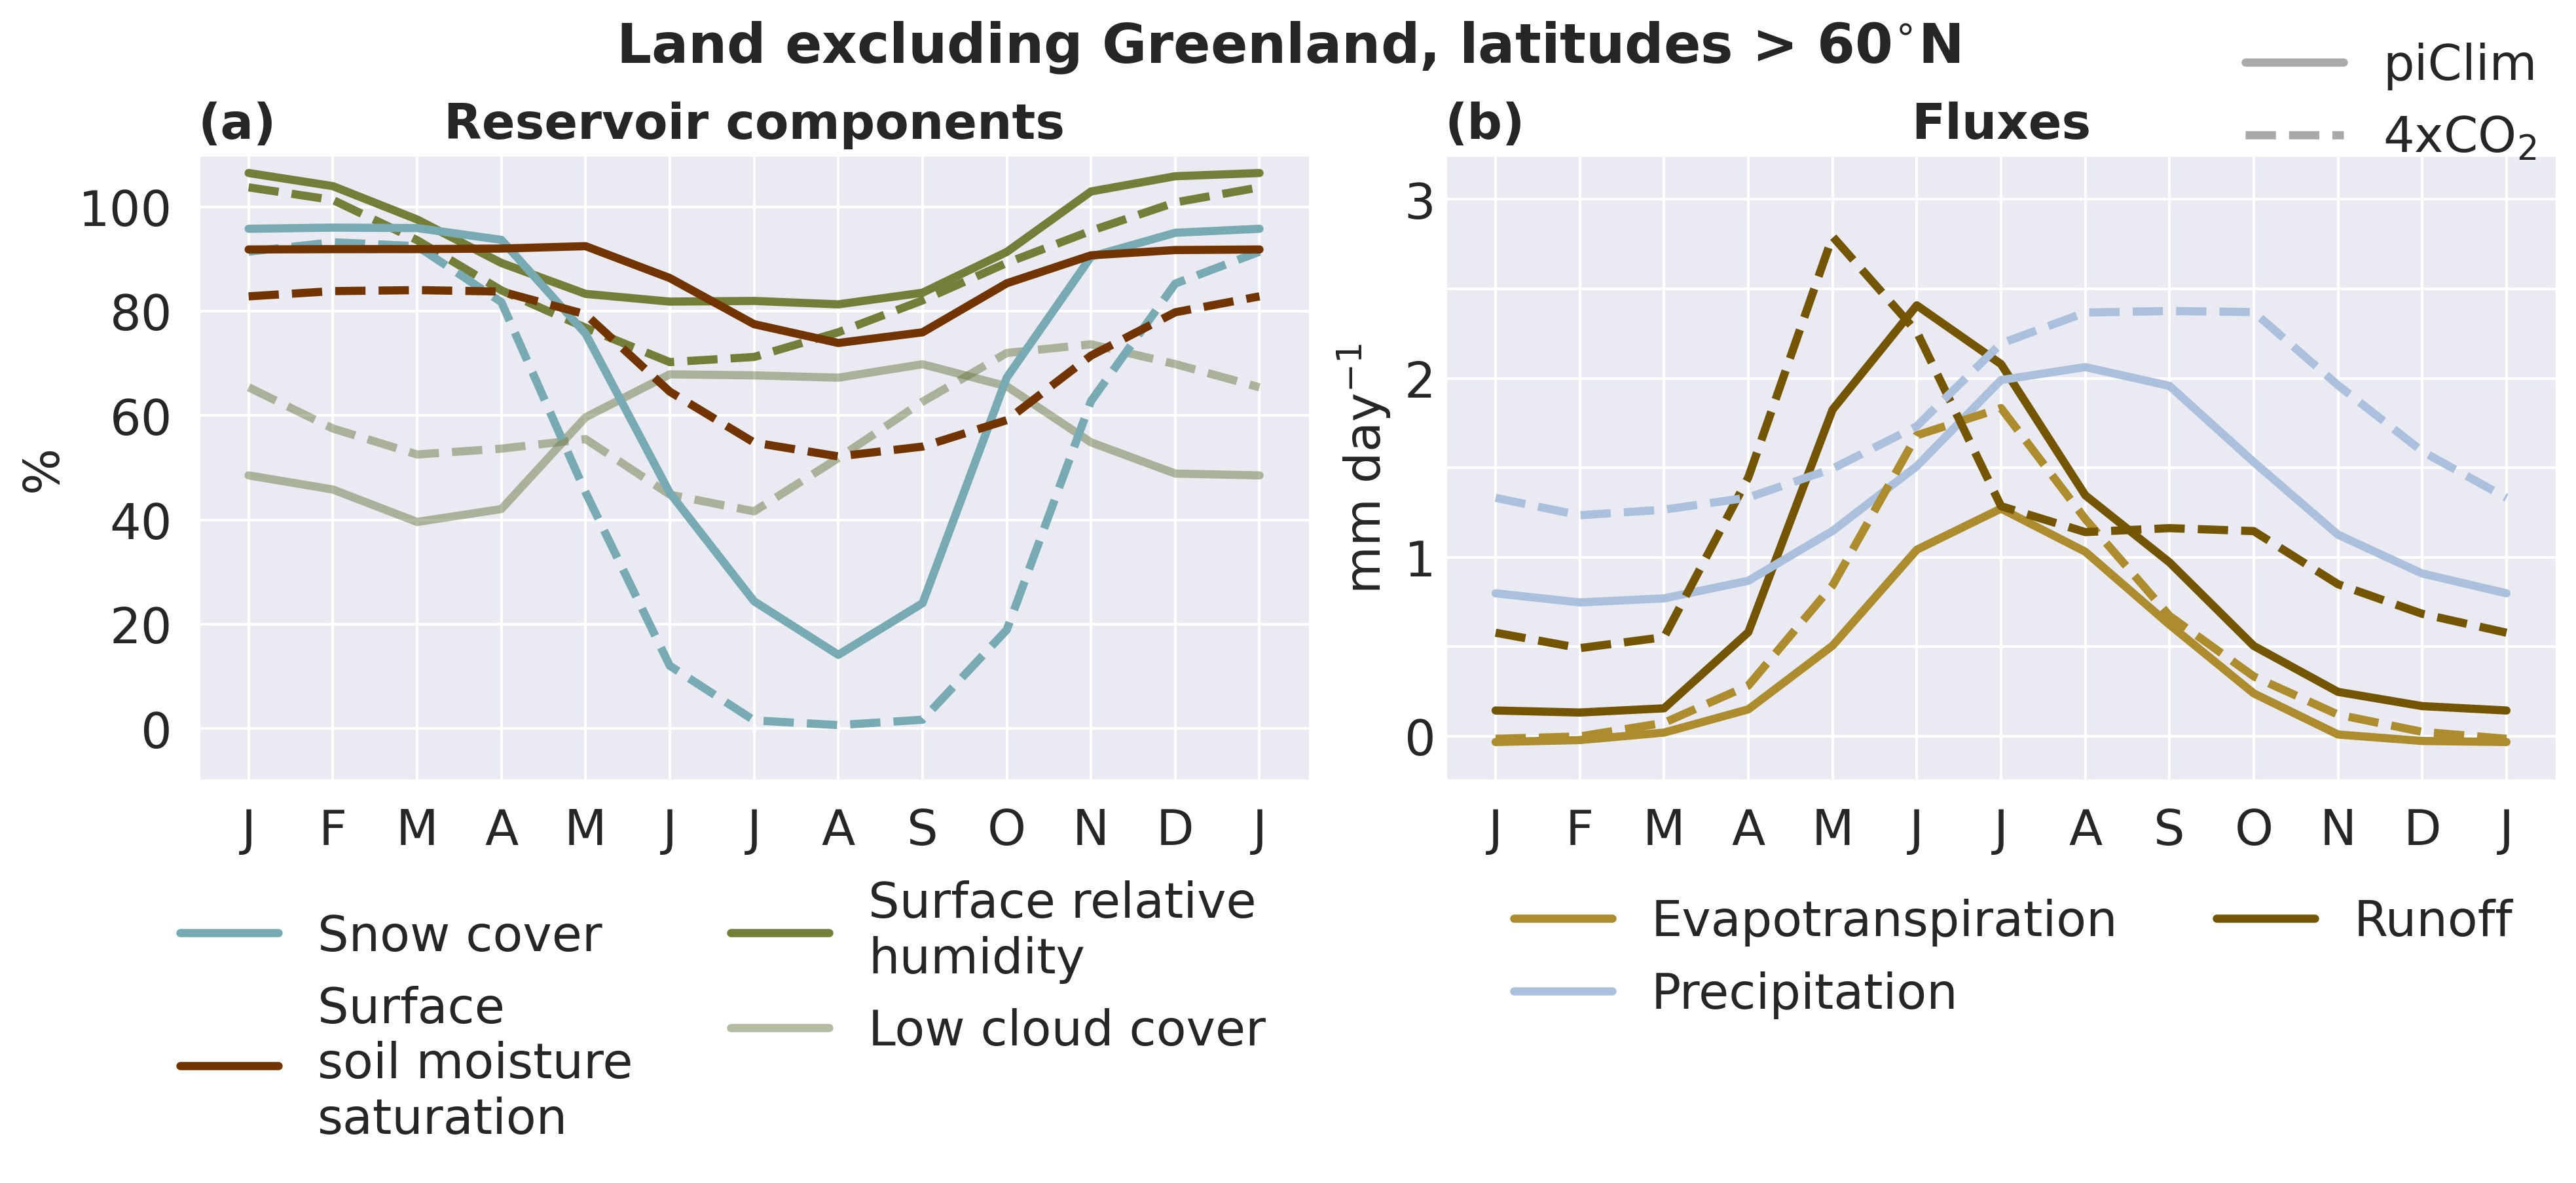

In [4]:
sns.set_theme()
months = np.arange(1, 14, 1)
monthnames = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D', 'J']

# Colors

SM_color = cmcrameri.cm.glasgow.colors[70]
SC_color = cmcrameri.cm.glasgow.colors[200]
SRH_color = cmcrameri.cm.batlow.colors[120]
LCC_color = cmcrameri.cm.glasgow.colors[140]

ET_color = cmcrameri.cm.batlow.colors[150]
P_color = cmcrameri.cm.glasgow.colors[230]
R_color = cmcrameri.cm.glasgow.colors[100]

labels = [['(a)','(b)']]
lw=3

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(13, 5),dpi=300,constrained_layout=True)

# Left: percentages
label = '(a)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_i, ds_4xCO2_i], ['piClim', '4xCO2'],['-','--']):
#for ds, name, ls in zip([ds_piClim_i], ['piClim'],['-']):

# Soil saturation
    for var, c in zip(['FSOILSAT_20CM'], [SM_color]):
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*100
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw,zorder=10)
    
    # Snow cover
    for var, c in zip(['FSNO'],  [SC_color]):
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*100
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw, zorder=3)


    # Surface relative humidity and clouds
    
    if name == '4xCO2':
        for var, c, ls in zip(['RELHUM','CLDLOW'], [SRH_color,LCC_color], ['--','--']):
            if var=='CLDLOW':
                avg = (ds_4xCO2_RH_lnd[var])*100
                avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
                ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw,zorder=1,alpha=0.5)
            else:
                avg = (ds_4xCO2_RH_lnd[var])
                avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
                ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw,zorder=2)
    elif name == 'piClim':
         for var, c, ls in zip(['RELHUM','CLDLOW'], [SRH_color,LCC_color], ['-','-']):
            if var=='CLDLOW':
                avg = (piClim_RH_lnd[var])*100
                avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
                ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw,zorder=1,alpha=0.5)
            else:
                avg = (piClim_RH_lnd[var])  
                avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
                ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw,zorder=2)
    
ax.set_title('Reservoir components', fontsize=18,fontweight='bold')
ax.set_ylim([-10,110])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
ax.set_ylabel('%', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)

# Right: fluxes
label = '(b)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_i, ds_4xCO2_i], ['piClim', '4xCO2'],['-','--']):
#for ds, name, ls in zip([ds_piClim_i], ['piClim'],['-']):
    # For flux variables
    for var, c in zip(['QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL'], [ET_color, R_color,P_color]):
        avg = (ds[var]*area_weights).sum(dim=['lon','lat'])*60*60*24
        avg_plus_J = list(avg.values)+[avg.isel(month=0).values]
        ax.plot(months, avg_plus_J, color=c, linestyle=ls, lw=lw)


ax.set_title('Fluxes', fontsize=18,fontweight='bold')
ax.set_ylim([-0.25,3.25])
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
ax.set_yticklabels([0, '', 1, '', 2, '', 3], fontsize=18)
ax.tick_params(axis='y', length=0.00001)
ax.set_ylabel('mm day$^{-1}$', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)



from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements_0 = [Line2D([0], [0], color='darkgrey', lw=lw, linestyle='-', label='piClim'),
                Line2D([0], [0], color='darkgrey', lw=lw, linestyle='--', label='4xCO$_2$'),]


legend_elements_1 = [Line2D([0], [0], color=SC_color, lw=lw, linestyle='-', label='Snow cover'),
                Line2D([0], [0], color=SM_color, lw=lw, linestyle='-', label='Surface\nsoil moisture\nsaturation'),
                Line2D([0], [0], color=SRH_color, lw=lw, linestyle='-', label='Surface relative\nhumidity'),
                Line2D([0], [0], color=LCC_color, lw=lw, linestyle='-', alpha=0.5,label='Low cloud cover')]

legend_elements_2 = [Line2D([0], [0], color=ET_color, lw=lw, linestyle='-', label='Evapotranspiration'),
                   Line2D([0], [0], color=P_color, lw=lw, linestyle='-', label='Precipitation'),
                   Line2D([0], [0], color=R_color, lw=lw, linestyle='-', label='Runoff')]

ax1 = axs['(b)'].twinx()
ax1.legend(handles=legend_elements_0, loc='upper left', bbox_to_anchor=(0.68, 1.25),frameon=False,
                fontsize=18,title_fontsize=18)
ax1.get_yaxis().set_visible(False)

axs['(a)'].legend(handles=legend_elements_1, loc='lower right', bbox_to_anchor=(1, -0.65),frameon=False,
                fontsize=18,title_fontsize=18,ncols=2)


axs['(b)'].legend(handles=legend_elements_2, loc='lower right', bbox_to_anchor=(1, -0.45),frameon=False,
                fontsize=18,title_fontsize=18,ncols=2)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
fig.suptitle('Land excluding Greenland, latitudes > 60$^{\circ}$N',fontsize=20,fontweight='bold')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.pdf',bbox_inches='tight')

plt.show()